# Phân phối của mọi feature

Notebook này vẽ phân phối của **mọi feature mà 3 bài đang dùng**, tính trên toàn bộ bảng
`flights_curated` (5,704,000 chuyến), theo đúng cách pipeline tính chúng:

- **Bài A** (hồi quy trước khi bay) và **bài C** (phân loại): `predeparture_v3`
- **Bài B** (hồi quy sau cất cánh, target `label_gain`): `wheelsoff_gain_nodep`

Bảng tóm tắt ở mục 2 tự gắn cờ những chỗ cần xem: giá trị thiếu, số âm ở cột không thể âm,
cột gần như toàn số 0, đuôi dài. Tính lại bằng `python scripts/build_feature_notebook.py`.

## 1. Tính các feature

In [1]:
import os, sys
import numpy as np
import pandas as pd
import pyarrow.dataset as ds
import matplotlib.pyplot as plt

REPO = os.path.abspath("..") if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
sys.path.insert(0, REPO)
from model_explain import _style, BLUE, INK, INK_2, SURFACE
%matplotlib inline

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)
plt.rcParams["figure.dpi"] = 110

cols = ["MONTH", "DAY", "TAIL_NUMBER", "FLIGHT_NUMBER", "AIRLINE", "ORIGIN_AIRPORT",
        "DESTINATION_AIRPORT", "SCHED_DEP_MIN", "SCHED_ARR_MIN", "ORIGIN_LAT", "ORIGIN_LON",
        "DEST_LAT", "DEST_LON", "DISTANCE", "SCHEDULED_TIME", "TAXI_OUT", "DEPARTURE_DELAY",
        "label_delay", "label_severe"]
d = ds.dataset(os.path.join(REPO, "data", "parquet", "flights_curated")).to_table(columns=cols).to_pandas()
print(f"{len(d):,} chuyến")

5,704,000 chuyến


In [2]:
# Vòng quay tàu bay: chuyến trước cùng TAIL_NUMBER trong ngày, chỉ tính khi nối đúng sân bay
# (giống mllib_pipeline.rotation_table).
d = d.sort_values(["TAIL_NUMBER", "MONTH", "DAY", "SCHED_DEP_MIN", "FLIGHT_NUMBER"]).reset_index(drop=True)
g = d.groupby(["TAIL_NUMBER", "MONTH", "DAY"], sort=False)
d["leg_of_day"] = g.cumcount() + 1.0
linked = g["DESTINATION_AIRPORT"].shift() == d["ORIGIN_AIRPORT"]
d["has_prev"] = linked.astype(float)
d["turn_slack"] = np.where(linked, d["SCHED_DEP_MIN"] - g["SCHED_ARR_MIN"].shift(), np.nan)
d["prev_arr_delay"] = np.where(linked, g["label_delay"].shift(), np.nan)
d["inbound_overrun"] = np.maximum(d["prev_arr_delay"] - d["turn_slack"], 0)

# Giờ dạng vòng tròn, quãng đường, tốc độ theo lịch, target của bài B.
d["hour_sin"] = np.sin(2 * np.pi * d["SCHED_DEP_MIN"] / 1440)
d["hour_cos"] = np.cos(2 * np.pi * d["SCHED_DEP_MIN"] / 1440)
d["log_distance"] = np.log1p(d["DISTANCE"])
d["sched_mph"] = d["DISTANCE"] / (d["SCHEDULED_TIME"] / 60)
d["label_gain"] = d["label_delay"] - d["DEPARTURE_DELAY"]

# sched_dest_hour: số chuyến dự kiến hạ cánh ở sân bay đích trong giờ đó, đếm từ lịch gốc
# (kể cả chuyến bị hủy), mã sân bay tháng 10 đã sửa bằng data/dot_to_iata.csv.
raw = ds.dataset(os.path.join(REPO, "data", "parquet", "flights_raw"), partitioning="hive").to_table(
    columns=["MONTH", "DAY", "DESTINATION_AIRPORT", "SCHEDULED_ARRIVAL"]).to_pandas()
code_map = pd.read_csv(os.path.join(REPO, "data", "dot_to_iata.csv"), dtype=str)
raw["DESTINATION_AIRPORT"] = raw["DESTINATION_AIRPORT"].replace(
    dict(zip(code_map["dot_code"], code_map["iata_code"])))
raw["MONTH"] = raw["MONTH"].astype(int)
raw["_h"] = (pd.to_numeric(raw["SCHEDULED_ARRIVAL"]) // 100 % 24).astype(int)
cnt = raw.groupby(["DESTINATION_AIRPORT", "MONTH", "DAY", "_h"]).size().rename("_n").reset_index()
d["_h"] = (d["SCHED_ARR_MIN"] // 60).astype(int)
d = d.merge(cnt, on=["DESTINATION_AIRPORT", "MONTH", "DAY", "_h"], how="left")
d["sched_dest_hour"] = np.log1p(d["_n"])
del raw, cnt

A_C = ["SCHED_ARR_MIN", "hour_sin", "hour_cos", "ORIGIN_LAT", "ORIGIN_LON", "DEST_LAT", "DEST_LON",
       "leg_of_day", "has_prev", "turn_slack", "prev_arr_delay", "inbound_overrun"]
B = ["TAXI_OUT", "log_distance", "sched_mph", "DISTANCE", "SCHEDULED_TIME", "sched_dest_hour",
     "SCHED_ARR_MIN", "hour_sin", "hour_cos", "ORIGIN_LAT", "ORIGIN_LON", "DEST_LAT", "DEST_LON"]
TARGETS = ["label_delay", "label_severe", "label_gain"]
print("A và C:", len(A_C), "cột số; B:", len(B), "cột số")

A và C: 12 cột số; B: 13 cột số


## 2. Bảng tóm tắt, có gắn cờ

Cột `cờ` được tính tự động:
- **thiếu**: hơn 1% ô trống (pipeline điền median của tập train)
- **âm**: có giá trị âm ở cột mà theo nghĩa không thể âm
- **toàn 0**: hơn 80% là 0
- **đuôi dài**: giá trị lớn nhất gấp hơn 5 lần phân vị 99
- **hằng số**: độ lệch chuẩn gần 0

In [3]:
NONNEG = {"leg_of_day", "turn_slack", "inbound_overrun", "TAXI_OUT", "DISTANCE", "SCHEDULED_TIME",
          "sched_mph", "log_distance", "sched_dest_hour", "SCHED_ARR_MIN", "has_prev"}

def summary(cols):
    rows = []
    for c in cols:
        x = d[c].astype(float)
        v = x.dropna()
        q = v.quantile([0.01, 0.5, 0.99])
        flags = []
        if x.isna().mean() > 0.01: flags.append("thiếu")
        if c in NONNEG and (v < 0).any(): flags.append(f"âm ({(v < 0).mean():.2%})")
        if (v == 0).mean() > 0.8: flags.append("toàn 0")
        if q[0.99] > 0 and v.max() > 5 * q[0.99]: flags.append("đuôi dài")
        if v.std() < 1e-9: flags.append("hằng số")
        rows.append({"feature": c, "thiếu": f"{x.isna().mean():.1%}", "bằng 0": f"{(v == 0).mean():.1%}",
                     "min": v.min(), "p1": q[0.01], "trung vị": q[0.5], "p99": q[0.99], "max": v.max(),
                     "TB": v.mean(), "lệch chuẩn": v.std(), "độ lệch (skew)": v.skew(),
                     "cờ": ", ".join(flags)})
    return pd.DataFrame(rows).set_index("feature").round(3)

print("Bài A và C")
display(summary(A_C))
print("Bài B (chỉ các cột khác bài A và C)")
display(summary([c for c in B if c not in A_C]))
print("Target")
display(summary(TARGETS))

Bài A và C


,thiếu,bằng 0,min,p1,trung vị,p99,max,TB,lệch chuẩn,độ lệch (skew),cờ
feature,,,,,,,,,,,
SCHED_ARR_MIN,0.0%,0.0%,0.000,44.000,920.000,1426.000,1439.000,907.539,304.381,-0.284,
hour_sin,0.0%,0.0%,-1.000,-1.000,-0.309,1.000,1.000,-0.129,0.736,0.299,
hour_cos,0.0%,0.0%,-1.000,-1.000,-0.500,0.966,1.000,-0.358,0.559,0.712,
ORIGIN_LAT,0.0%,0.0%,13.483,20.899,37.362,47.482,71.285,36.640,5.997,-0.049,
ORIGIN_LON,0.0%,0.0%,-176.646,-157.922,-90.258,-71.005,-64.799,-95.574,18.182,-0.953,
DEST_LAT,0.0%,0.0%,13.483,20.899,37.362,47.482,71.285,36.640,5.999,-0.049,
DEST_LON,0.0%,0.0%,-176.646,-157.922,-90.258,-71.005,-64.799,-95.574,18.187,-0.953,
leg_of_day,0.0%,0.0%,1.000,1.000,3.000,8.000,16.000,3.042,1.816,0.944,
has_prev,0.0%,24.6%,0.000,0.000,1.000,1.000,1.000,0.754,0.431,-1.180,


Bài B (chỉ các cột khác bài A và C)


,thiếu,bằng 0,min,p1,trung vị,p99,max,TB,lệch chuẩn,độ lệch (skew),cờ
feature,,,,,,,,,,,
TAXI_OUT,0.0%,0.0%,1.000,6.000,14.000,50.000,225.000,16.070,8.884,3.460,
log_distance,0.0%,0.0%,3.466,4.615,6.479,7.859,8.514,6.449,0.761,-0.267,
sched_mph,0.0%,0.0%,57.429,117.818,322.353,475.777,901.765,315.013,82.296,-0.332,
DISTANCE,0.0%,0.0%,31.000,100.000,650.000,2588.000,4983.000,825.048,608.822,1.416,
SCHEDULED_TIME,0.0%,0.0%,18.000,44.000,123.000,377.000,718.000,141.973,75.334,1.339,
sched_dest_hour,0.0%,0.0%,0.693,0.693,2.833,4.454,4.635,2.694,1.031,-0.339,


Target


,thiếu,bằng 0,min,p1,trung vị,p99,max,TB,lệch chuẩn,độ lệch (skew),cờ
feature,,,,,,,,,,,
label_delay,0.0%,2.2%,-87.0,-34.0,-5.0,167.0,1971.0,4.411,39.272,6.498,đuôi dài
label_severe,0.0%,88.9%,0.0,0.0,0.0,1.0,1.0,0.111,0.314,2.481,toàn 0
label_gain,0.0%,3.1%,-201.0,-33.0,-6.0,36.0,330.0,-4.887,12.887,1.473,đuôi dài


## 3. Histogram từng cột số

Mỗi hình vẽ phần giữa phân vị 0.1 và 99.9. Phần nằm ngoài không bị dồn về mép (sẽ tạo đỉnh
giả) mà được bỏ khỏi hình; tiêu đề ghi giá trị lớn nhất và tỷ lệ bị bỏ. Cột có đuôi dài dùng
trục đếm thang log. Đường nét đứt là trung vị.

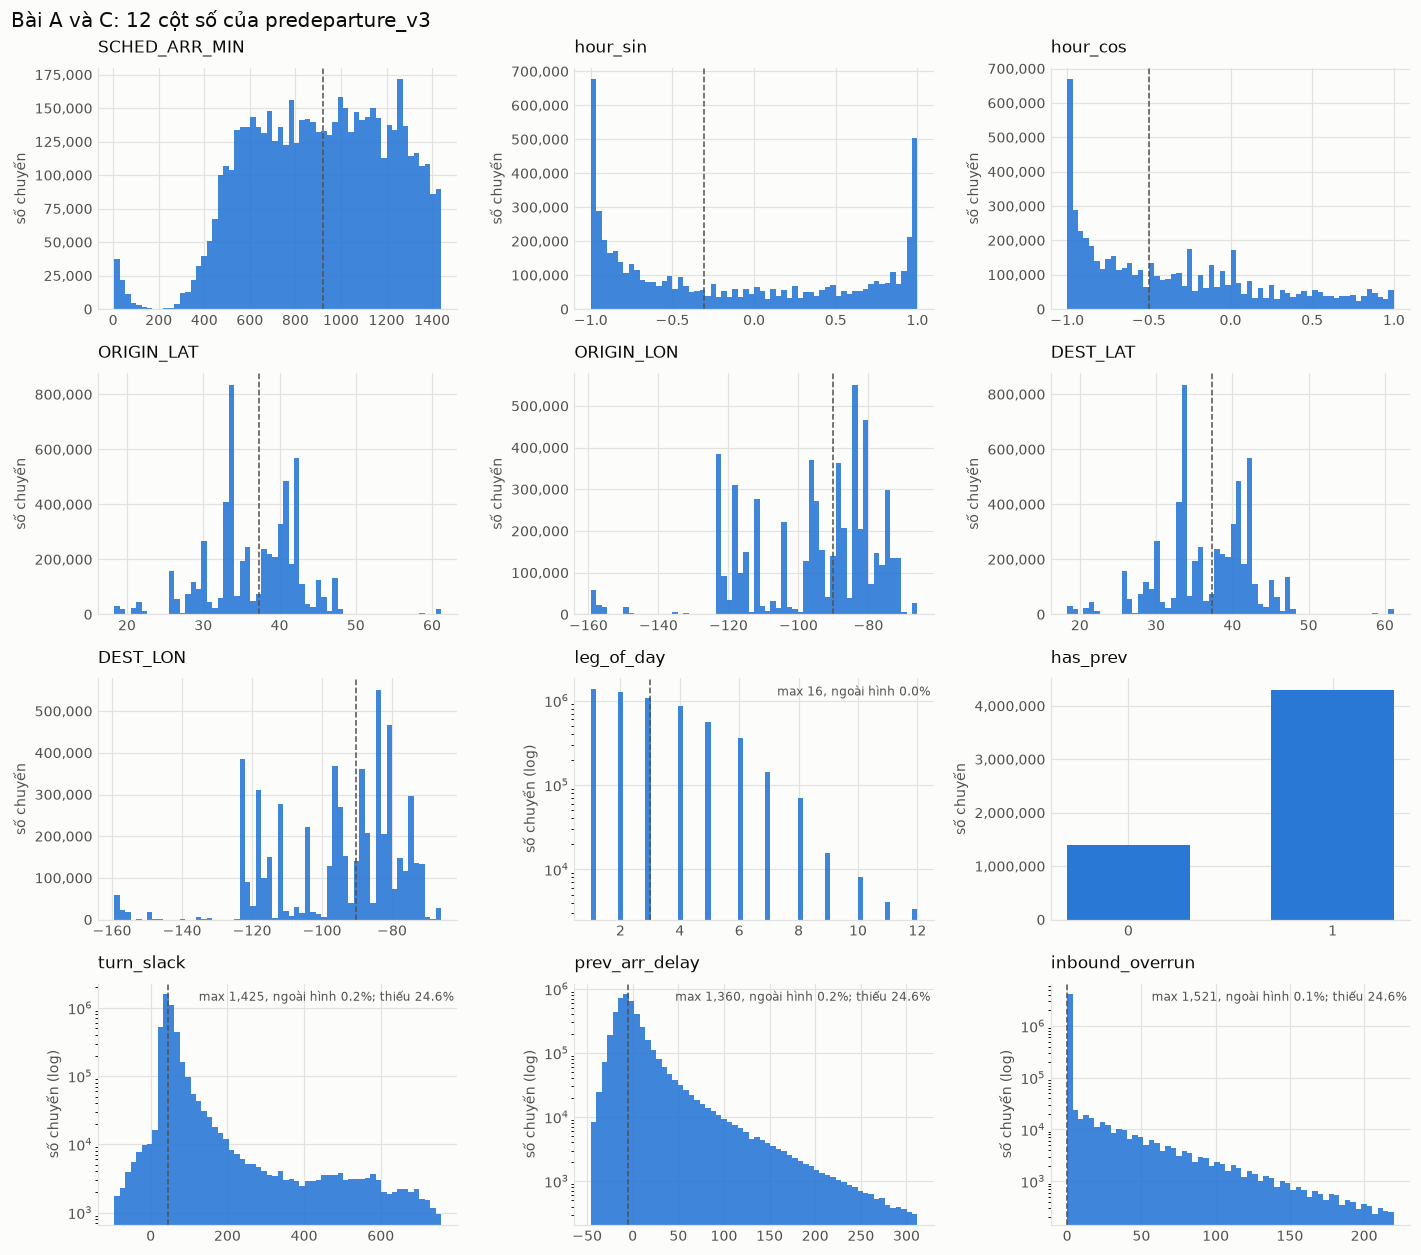

In [4]:
LOGY = {"turn_slack", "prev_arr_delay", "inbound_overrun", "TAXI_OUT", "sched_mph", "leg_of_day",
        "label_delay", "label_gain"}

def grid(cols, title):
    n = len(cols); ncol = 3; nrow = -(-n // ncol)
    fig, axes = plt.subplots(nrow, ncol, figsize=(13, 2.9 * nrow))
    for ax, c in zip(axes.flat, cols):
        v = d[c].dropna().astype(float)
        lo, hi = v.quantile(0.001), v.quantile(0.999)
        if c in ("has_prev", "label_severe"):
            ax.bar([0, 1], [(v == 0).sum(), (v == 1).sum()], color=BLUE, width=0.6)
            ax.set_xticks([0, 1])
        else:
            inside = v[(v >= lo) & (v <= hi)]
            ax.hist(inside, bins=60, color=BLUE, alpha=0.9)
            ax.axvline(v.median(), color=INK_2, linestyle="--", linewidth=1)
        if c in LOGY:
            ax.set_yscale("log")
        miss = d[c].isna().mean()
        cut = 1 - ((v >= lo) & (v <= hi)).mean()
        notes = []
        if c in LOGY:
            notes.append(f"max {v.max():,.0f}, ngoài hình {cut:.1%}")
        if miss > 0.01:
            notes.append(f"thiếu {miss:.1%}")
        _style(ax, "", "số chuyến" + (" (log)" if c in LOGY else ""),
               c)
        if notes:
            ax.text(0.99, 0.97, "; ".join(notes), transform=ax.transAxes, ha="right", va="top",
                    fontsize=8, color=INK_2)
        ax.ticklabel_format(axis="y", style="plain") if c not in LOGY else None
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}")) if c not in LOGY else None
    for ax in list(axes.flat)[n:]:
        ax.set_visible(False)
    fig.suptitle(title, x=0.01, ha="left", color=INK, fontsize=13)
    fig.tight_layout()
    plt.show()

grid(A_C, "Bài A và C: 12 cột số của predeparture_v3")

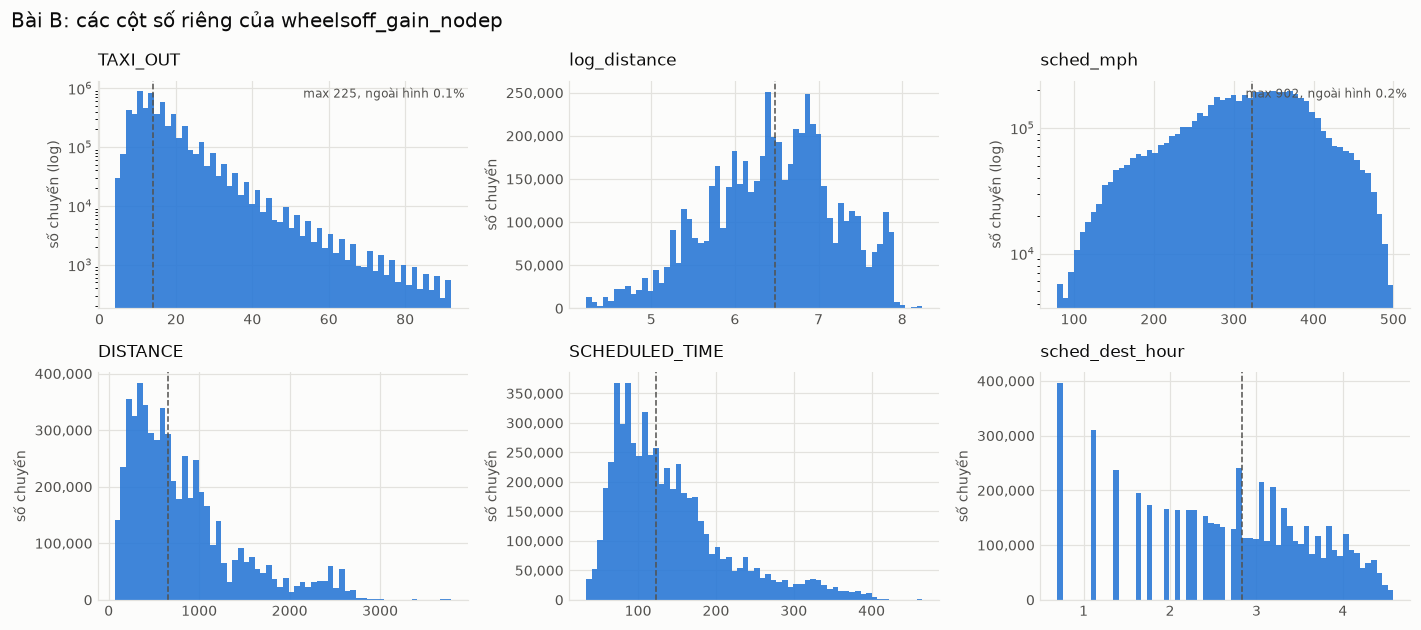

In [5]:
grid([c for c in B if c not in A_C], "Bài B: các cột số riêng của wheelsoff_gain_nodep")

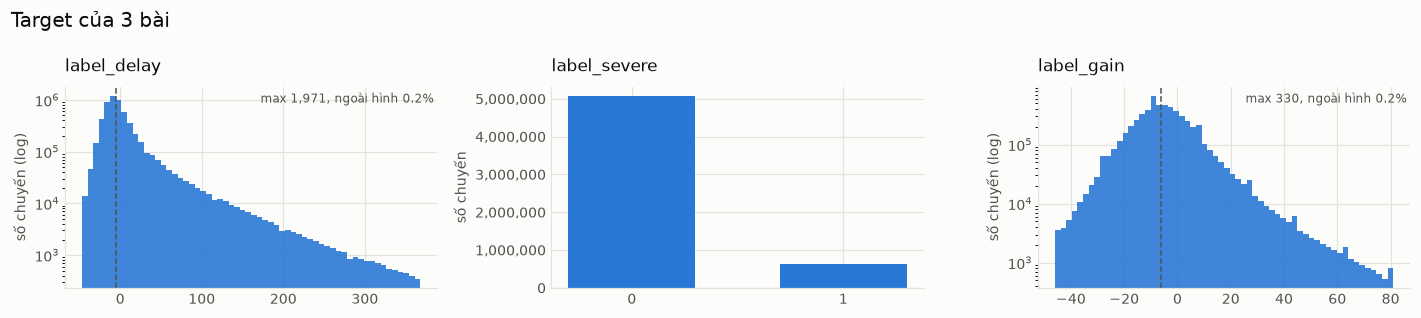

In [6]:
grid(TARGETS, "Target của 3 bài")

## 4. Cột phân loại (one-hot)

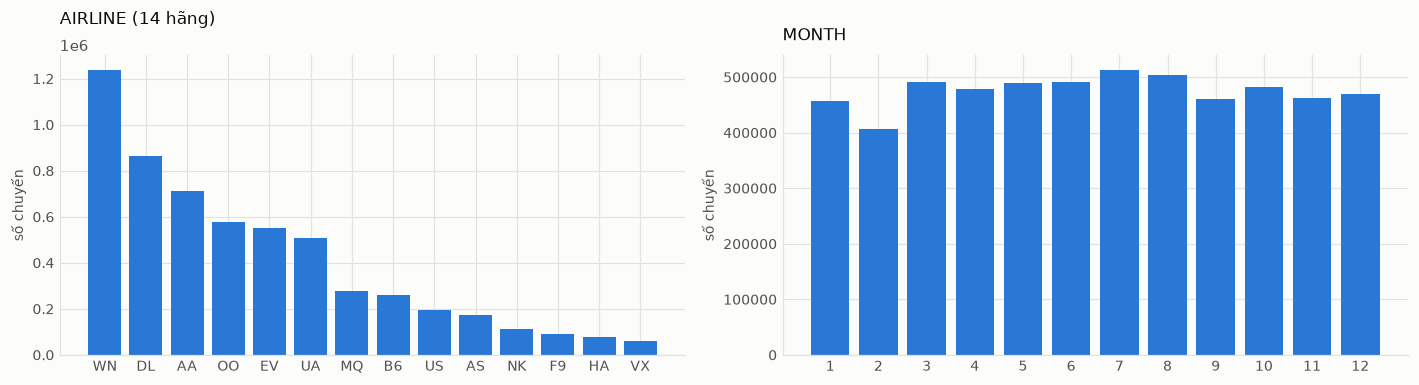

Hãng ít chuyến nhất: VX 61,248 (1.1%)


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 3.6))
a = d["AIRLINE"].value_counts()
axes[0].bar(a.index, a.values, color=BLUE)
_style(axes[0], "", "số chuyến", "AIRLINE (14 hãng)")
m = d["MONTH"].value_counts().sort_index()
axes[1].bar(m.index.astype(str), m.values, color=BLUE)
_style(axes[1], "", "số chuyến", "MONTH")
fig.tight_layout(); plt.show()
print("Hãng ít chuyến nhất:", a.idxmin(), f"{a.min():,}", f"({a.min() / len(d):.1%})")

## 5. Soi kỹ những cột bị gắn cờ

In [8]:
s = d["turn_slack"]
print(f"turn_slack âm: {(s < 0).sum():,} chuyến ({(s < 0).mean():.2%} số chuyến có chuyến trước)")
print("  phân vị âm:", s[s < 0].quantile([0.01, 0.5, 0.99]).round(0).to_dict())
print(f"turn_slack trên 12 tiếng: {(s > 720).sum():,}")
sp = d["sched_mph"]
print(f"\nsched_mph trên 550 mph: {(sp > 550).sum():,}; dưới 60 mph: {(sp < 60).sum():,}")
display(d.loc[sp > 550, ["AIRLINE", "ORIGIN_AIRPORT", "DESTINATION_AIRPORT", "DISTANCE", "SCHEDULED_TIME", "sched_mph"]].head(12))
print(f"\nsched_dest_hour thiếu (không khớp lịch gốc): {d['sched_dest_hour'].isna().sum():,}")
print(f"inbound_overrun > 300 phút: {(d['inbound_overrun'] > 300).sum():,}")

turn_slack âm: 40,910 chuyến (0.72% số chuyến có chuyến trước)
  phân vị âm: {0.01: -226.0, 0.5: -32.0, 0.99: -1.0}
turn_slack trên 12 tiếng: 7,193

sched_mph trên 550 mph: 12; dưới 60 mph: 56


,AIRLINE,ORIGIN_AIRPORT,DESTINATION_AIRPORT,DISTANCE,SCHEDULED_TIME,sched_mph
897183,AS,ANC,PDX,1542,154,600.779221
938067,AS,SEA,FAI,1533,102,901.764706
1663491,AS,SEA,BOS,2496,251,596.653386
1706524,AS,SEA,MCO,2554,261,587.126437
1982952,AS,LAX,BWI,2329,245,570.367347
2737688,AS,SEA,ANC,1448,155,560.516129
2755518,AS,ANC,ORD,2846,303,563.564356
2991562,AS,PDX,ANC,1542,165,560.727273
3272948,DL,HNL,ATL,4502,491,550.142566
3735952,EV,RST,CLE,569,59,578.644068



sched_dest_hour thiếu (không khớp lịch gốc): 0
inbound_overrun > 300 phút: 1,581


In [9]:
# label_gain cực trị: bù lại hơn 1 tiếng trên không, hoặc mất thêm hơn 3 tiếng.
lg = d["label_gain"]
print(f"label_gain < -60: {(lg < -60).sum():,}   < -120: {(lg < -120).sum():,}   > 180: {(lg > 180).sum():,}")
show = ["AIRLINE", "ORIGIN_AIRPORT", "DESTINATION_AIRPORT", "SCHEDULED_TIME", "DISTANCE",
        "DEPARTURE_DELAY", "label_delay", "TAXI_OUT", "label_gain"]
display(d.loc[lg < -120, show].sort_values("label_gain").head(10))
# Tốc độ theo lịch dưới 60 mph: quãng đường rất ngắn so với thời gian lịch.
display(d.loc[d["sched_mph"] < 60, show[:5] + ["sched_mph"]].head(10))

label_gain < -60: 278   < -120: 1   > 180: 36

,AIRLINE,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_TIME,DISTANCE,DEPARTURE_DELAY,label_delay,TAXI_OUT,label_gain
825116,VX,SAN,SFO,285,447,184,-17.0,10,-201.0


,AIRLINE,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_TIME,DISTANCE,sched_mph
1697307,OO,MKE,ORD,68,67,59.117647
1697327,OO,MKE,ORD,68,67,59.117647
1697333,OO,MKE,ORD,68,67,59.117647
1697357,OO,MKE,ORD,68,67,59.117647
1697362,OO,MKE,ORD,68,67,59.117647
1697374,OO,MKE,ORD,68,67,59.117647
1697394,OO,MKE,ORD,68,67,59.117647
1697414,OO,MKE,ORD,68,67,59.117647
1697428,OO,MKE,ORD,68,67,59.117647
1697450,OO,MKE,ORD,68,67,59.117647


## 6. Kết luận: có vấn đề gì không

**Không có lỗi dữ liệu nào đáng sửa.** Những gì bị gắn cờ đều là thiết kế, sự kiện có thật,
hoặc lỗi lẻ tẻ quá ít để ảnh hưởng model.

| cột | bị gắn cờ | đánh giá |
|---|---|---|
| `turn_slack`, `prev_arr_delay`, `inbound_overrun` | thiếu 24.6% | **thiết kế**: chuyến đầu ngày không có chuyến trước. Pipeline điền median của train (lần lượt 46, −5, 0 phút) và `has_prev` = 0 báo cho model đó là giá trị điền |
| `turn_slack` | âm ở 0.72% (40,910 chuyến), thấp nhất −523 | **có thật**: theo lịch chuyến trước đến sau giờ chuyến này đi, tức hãng đổi máy bay. Giữ nguyên, `inbound_overrun` khi đó lớn hơn `prev_arr_delay`, đúng thực tế |
| `turn_slack` | trên 12 tiếng: 7,193 chuyến | máy bay đỗ cả ngày giữa hai chuyến, hợp lý; quá ít để ảnh hưởng |
| `inbound_overrun` | 93.8% bằng 0 | **thiết kế**: phần lớn chuyến trước về kịp. Đây là dạng bản lề, model cây cắt được |
| `prev_arr_delay`, `inbound_overrun`, `TAXI_OUT`, các target | đuôi dài (tối đa 1,360 đến 1,971 phút) | **có thật** (bão, dừng cất cánh). Không cắt IQR; trần chỉ đặt ở điểm bão hòa hoặc điểm gãy đo được (đang test cap60, cap300) |
| `sched_mph` | 12 chuyến trên 550 mph | **lỗi dữ liệu**: 10 của Alaska, 1 của ExpressJet (RST đến CLE 578 mph); HNL đến ATL 550 mph là thật. 12 trên 5.7 triệu, không đáng xử lý |
| `sched_mph` | 56 chuyến dưới 60 mph | **có thật**: MKE đến ORD 67 dặm, lịch 68 phút, chủ yếu là lăn và chờ |
| `label_gain` | thấp nhất −201 phút | **1 lỗi dữ liệu**: VX SAN đến SFO ghi lịch 285 phút (bình thường khoảng 90). Chỉ 278 chuyến bù hơn 1 tiếng |
| tọa độ | cụm ở vĩ độ 13 đến 21 và 60 đến 71, kinh độ −176 | **có thật**: Guam, Hawaii, Alaska |
| `hour_sin`, `hour_cos` | dồn về ±1 | tính chất của hàm sin, không phải lỗi |
| `AIRLINE`, `MONTH` | VX ít nhất (1.1%), tháng 2 ít nhất | có thật (hãng nhỏ, tháng 2 có 28 ngày) |
